<a href="https://colab.research.google.com/github/nguyenvanminhhieu-hash/AI/blob/H%E1%BB%8Dc-M%C3%A1y/H%E1%BB%8DcM%C3%A1y_BTTL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **BÀI 1: CÀI ĐẶT LẠI THUẬT TOÁN K-MEANS**

Kích thước dữ liệu: (300, 2)
Tâm cụm:
[[-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]
 [-2.63323268  9.04356978]]


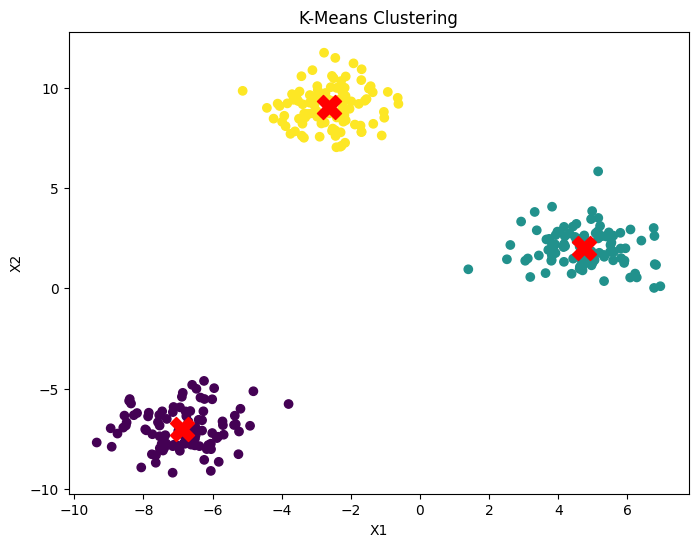

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class KMeans:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None

    # Hàm tính khoảng cách Euclidean
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    # Khởi tạo tâm cụm ngẫu nhiên
    def initialize_centroids(self, X):
        random_indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_indices]

    # Gán nhãn cụm cho từng điểm
    def assign_clusters(self, X):
        clusters = []

        for point in X:
            distances = [self.euclidean_distance(point, centroid)
                         for centroid in self.centroids]

            cluster = np.argmin(distances)
            clusters.append(cluster)

        return np.array(clusters)

    # Cập nhật tâm cụm
    def update_centroids(self, X, labels):
        new_centroids = []

        for i in range(self.k):
            cluster_points = X[labels == i]

            if len(cluster_points) > 0:
                centroid = np.mean(cluster_points, axis=0)
            else:
                centroid = self.centroids[i]

            new_centroids.append(centroid)

        return np.array(new_centroids)

    # Huấn luyện mô hình
    def fit(self, X):
        self.initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self.assign_clusters(X)

            new_centroids = self.update_centroids(X, labels)

            # Kiểm tra hội tụ
            if np.all(self.centroids == new_centroids):
                break

            self.centroids = new_centroids

        self.labels = labels

    # Dự đoán
    def predict(self, X):
        return self.assign_clusters(X)

    # Tạo dữ liệu giả lập
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

print("Kích thước dữ liệu:", X.shape)

# Khởi tạo mô hình
kmeans = KMeans(k=3)

# Huấn luyện
kmeans.fit(X)

# Lấy nhãn
labels = kmeans.labels

# In tâm cụm
print("Tâm cụm:")
print(kmeans.centroids)

plt.figure(figsize=(8,6))

# Vẽ dữ liệu
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')

# Vẽ tâm cụm
plt.scatter(
    kmeans.centroids[:,0],
    kmeans.centroids[:,1],
    c='red',
    s=300,
    marker='X'
)

plt.title('K-Means Clustering')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

### **BÀI 2: CÀI ĐẶT LẠI THUẬT TOÁN k-NN VỚI 2 CÁCH ĐÁNH GIÁ TRỌNG SỐ K**

In [2]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

class KNN:
    def __init__(self, k=3, weighted=False):
        self.k = k
        self.weighted = weighted

    # Hàm tính khoảng cách Euclidean
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    # Huấn luyện
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    # Dự đoán 1 điểm dữ liệu
    def predict_single(self, x):
        distances = []

        # Tính khoảng cách
        for x_train in self.X_train:
            distance = self.euclidean_distance(x, x_train)
            distances.append(distance)

        distances = np.array(distances)

        # Lấy k láng giềng gần nhất
        k_indices = distances.argsort()[:self.k]
        k_labels = self.y_train[k_indices]
        k_distances = distances[k_indices]

        # Cách 1: Voting thông thường
        if not self.weighted:
            most_common = Counter(k_labels).most_common(1)
            return most_common[0][0]

        # Cách 2: Weighted Voting
        else:
            class_scores = {}

            for label, distance in zip(k_labels, k_distances):
                weight = 1 / (distance + 1e-5)

                if label not in class_scores:
                    class_scores[label] = 0

                class_scores[label] += weight

            return max(class_scores, key=class_scores.get)

    # Dự đoán nhiều điểm
    def predict(self, X):
        predictions = [self.predict_single(x) for x in X]
        return np.array(predictions)

    # Load dữ liệu
iris = load_iris()
X = iris.data
y = iris.target

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Khởi tạo mô hình
knn_normal = KNN(k=5, weighted=False)

# Huấn luyện
knn_normal.fit(X_train, y_train)

# Dự đoán
y_pred_normal = knn_normal.predict(X_test)

# Đánh giá
accuracy_normal = accuracy_score(y_test, y_pred_normal)

print("Accuracy k-NN thường:", accuracy_normal)

# Khởi tạo mô hình
knn_weighted = KNN(k=5, weighted=True)

# Huấn luyện
knn_weighted.fit(X_train, y_train)

# Dự đoán
y_pred_weighted = knn_weighted.predict(X_test)

# Đánh giá
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)

print("Accuracy k-NN weighted:", accuracy_weighted)

print("="*40)
print("SO SÁNH KẾT QUẢ")
print("="*40)
print(f"k-NN thường   : {accuracy_normal:.4f}")
print(f"k-NN weighted : {accuracy_weighted:.4f}")

Accuracy k-NN thường: 1.0
Accuracy k-NN weighted: 1.0
SO SÁNH KẾT QUẢ
k-NN thường   : 1.0000
k-NN weighted : 1.0000


### **BÀI 3: CÀI ĐẶT ỨNG DỤNG DEMO CHO 2 THUẬT TOÁN**

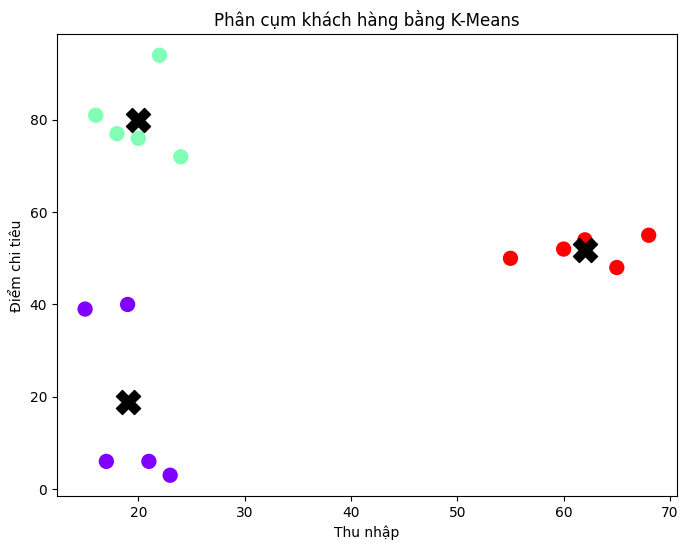

In [3]:
# Demo K-Means phân cụm khách hàng

import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu khách hàng
customer_data = np.array([
    [15, 39],
    [16, 81],
    [17, 6],
    [18, 77],
    [19, 40],
    [20, 76],
    [21, 6],
    [22, 94],
    [23, 3],
    [24, 72],
    [55, 50],
    [60, 52],
    [62, 54],
    [65, 48],
    [68, 55]
])

# Huấn luyện K-Means
kmeans_demo = KMeans(k=3)
kmeans_demo.fit(customer_data)

labels = kmeans_demo.labels

# Trực quan hóa
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data[:,0],
    customer_data[:,1],
    c=labels,
    cmap='rainbow',
    s=100
)

plt.scatter(
    kmeans_demo.centroids[:,0],
    kmeans_demo.centroids[:,1],
    c='black',
    marker='X',
    s=300
)

plt.xlabel('Thu nhập')
plt.ylabel('Điểm chi tiêu')
plt.title('Phân cụm khách hàng bằng K-Means')
plt.show()

In [ ]:
#

# Load dữ liệu
iris = load_iris()

X = iris.data
y = iris.target

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)

# Chuẩn hóa
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Huấn luyện k-NN weighted
model = KNN(k=3, weighted=True)
model.fit(X_train, y_train)

# Dự đoán
predictions = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, predictions)

pr